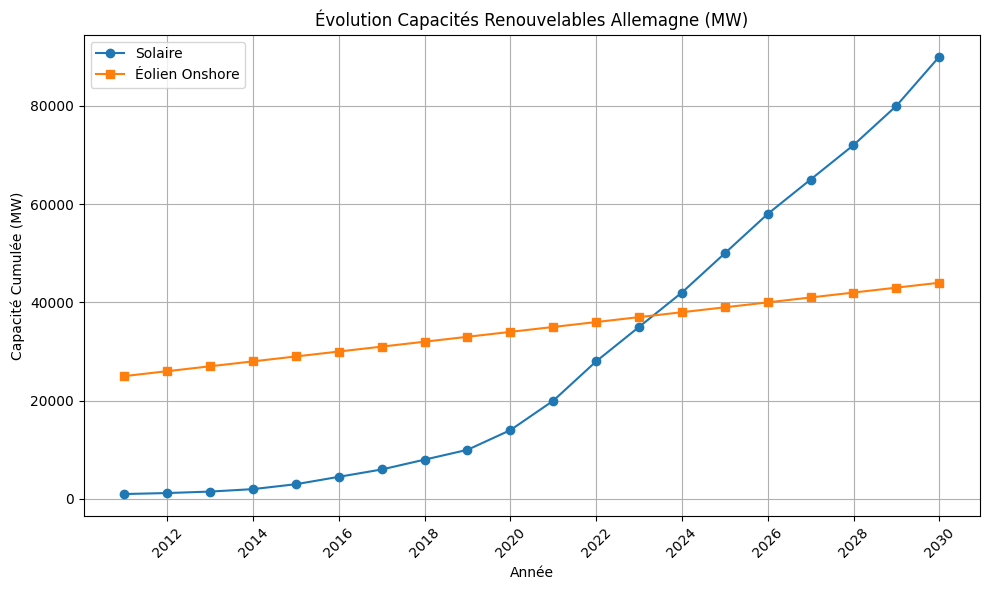

Prédictions solaires 2030-2034 (MW): [79838.42105263 84626.84210526 89415.26315789 94203.68421053
 98992.10526316]


In [1]:
# Installation des librairies (exécuter une fois)
!pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import io

# Dataset CSV (énergie renouvelable Allemagne, capacité cumulée MW)
csv_data = """date,DE_solar_capacity,DE_wind_onshore_capacity
2010-12-31,1000,25000
2011-12-31,1200,26000
2012-12-31,1500,27000
2013-12-31,2000,28000
2014-12-31,3000,29000
2015-12-31,4500,30000
2016-12-31,6000,31000
2017-12-31,8000,32000
2018-12-31,10000,33000
2019-12-31,14000,34000
2020-12-31,20000,35000
2021-12-31,28000,36000
2022-12-31,35000,37000
2023-12-31,42000,38000
2024-12-31,50000,39000
2025-12-31,58000,40000
2026-12-31,65000,41000
2027-12-31,72000,42000
2028-12-31,80000,43000
2029-12-31,90000,44000"""

# Chargement des données
df = pd.read_csv(io.StringIO(csv_data))
df['date'] = pd.to_datetime(df['date'])

# Graphique
plt.figure(figsize=(10,6))
plt.plot(df['date'], df['DE_solar_capacity'], label='Solaire', marker='o')
plt.plot(df['date'], df['DE_wind_onshore_capacity'], label='Éolien Onshore', marker='s')
plt.title('Évolution Capacités Renouvelables Allemagne (MW)')
plt.xlabel('Année')
plt.ylabel('Capacité Cumulée (MW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Prédiction simple (exemple linéaire pour solaire)
from sklearn.linear_model import LinearRegression
df_pred = df[['DE_solar_capacity']].copy()
df_pred['year'] = df['date'].dt.year
X = df_pred[['year']]
y = df_pred['DE_solar_capacity']
model = LinearRegression().fit(X, y)
future_years = pd.DataFrame({'year': range(2030, 2035)})
pred = model.predict(future_years)
print("Prédictions solaires 2030-2034 (MW):", pred)

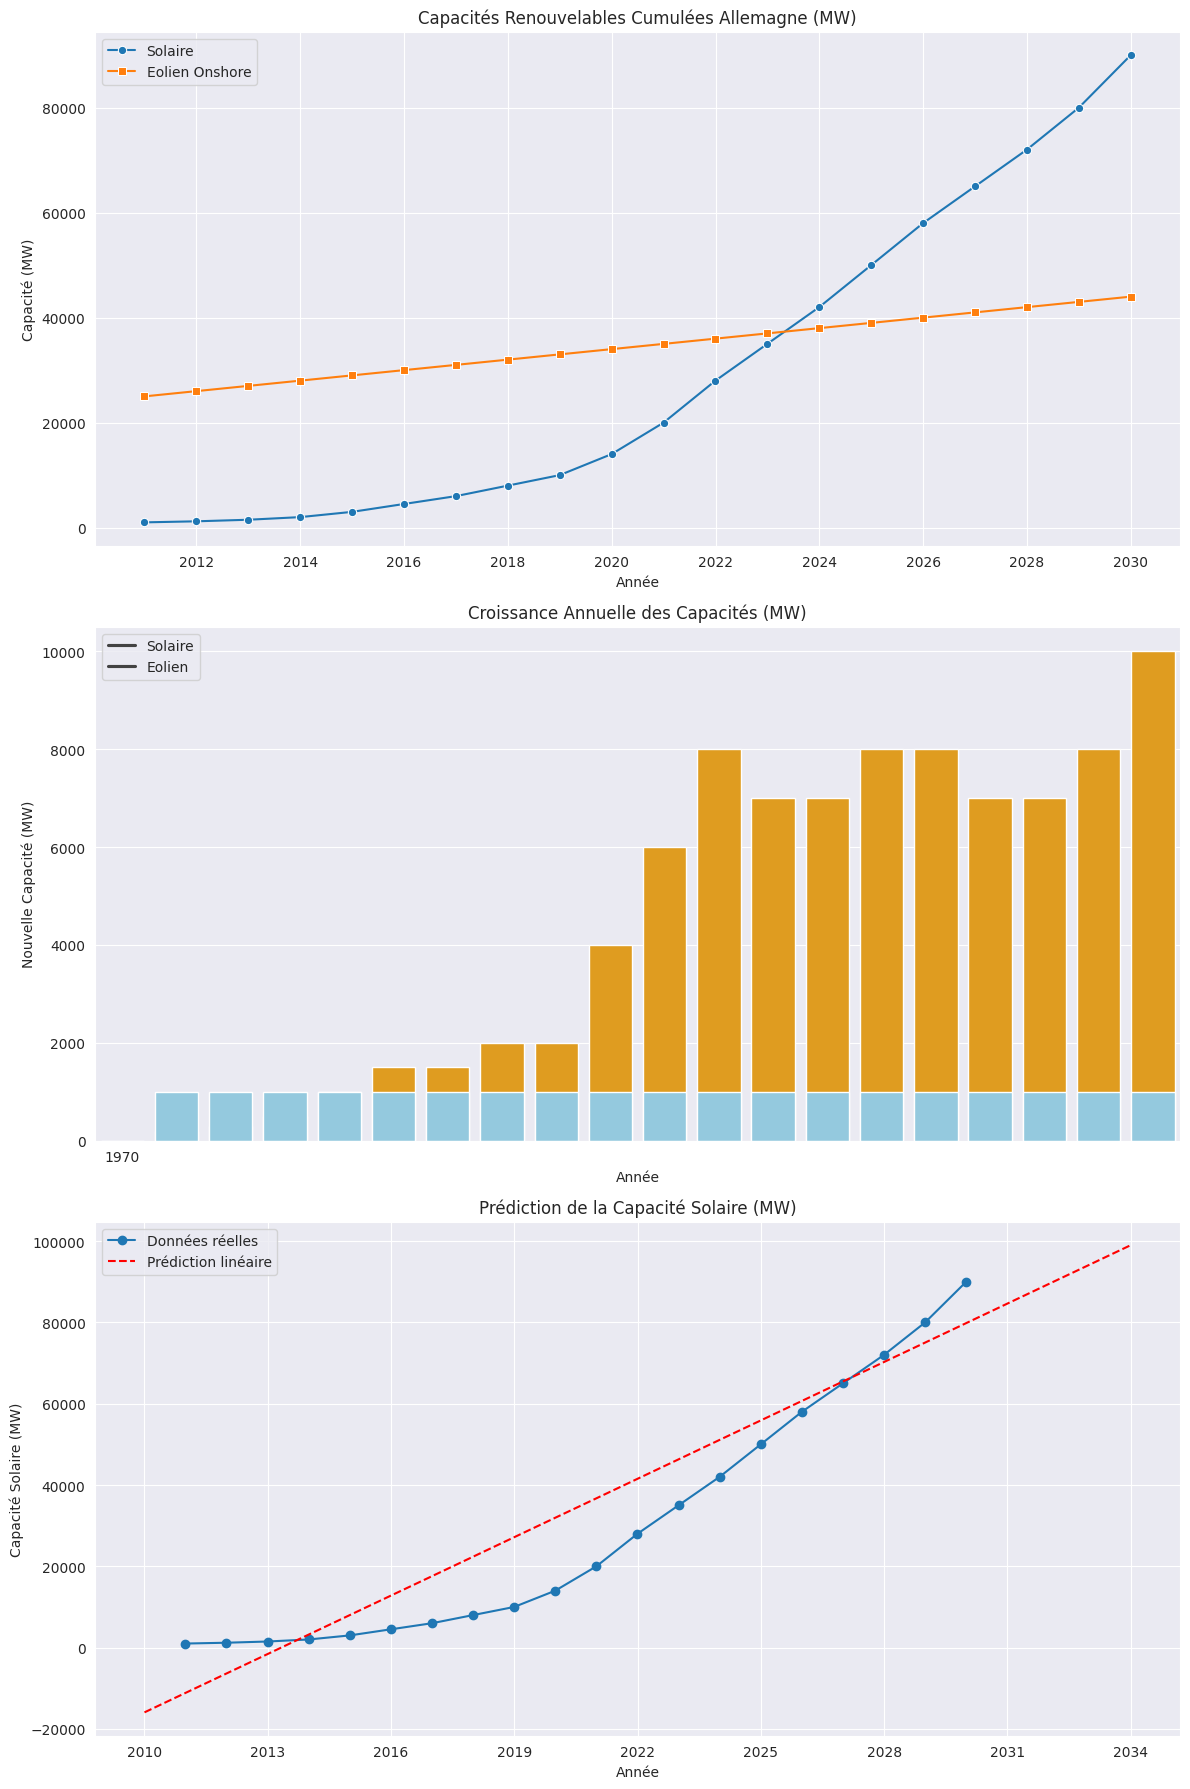

Erreur quadratique moyenne RMSE du modèle : 9100.27 MW
Prédictions solaires 2030-2034 (MW): [79838.42105263 84626.84210526 89415.26315789 94203.68421053
 98992.10526316]


In [2]:
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_squared_error
import numpy as np

# Amélioration du graphique avec plusieurs sous-graphes et styles
sns.set_style('darkgrid')

fig, axs = plt.subplots(3, 1, figsize=(12, 18))

# Graphique 1: Capacités solaires et éoliennes cumulées
sns.lineplot(data=df, x='date', y='DE_solar_capacity', marker='o', label='Solaire', ax=axs[0])
sns.lineplot(data=df, x='date', y='DE_wind_onshore_capacity', marker='s', label='Eolien Onshore', ax=axs[0])
axs[0].set_title('Capacités Renouvelables Cumulées Allemagne (MW)')
axs[0].set_xlabel('Année')
axs[0].set_ylabel('Capacité (MW)')
axs[0].xaxis.set_major_locator(mdates.YearLocator(2))
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs[0].legend()

# Graphique 2: Evolution annuelle des capacités (différences)
df['solar_growth'] = df['DE_solar_capacity'].diff().fillna(0)
df['wind_growth'] = df['DE_wind_onshore_capacity'].diff().fillna(0)
sns.barplot(x='date', y='solar_growth', data=df, color='orange', ax=axs[1], label='Croissance solaire')
sns.barplot(x='date', y='wind_growth', data=df, color='skyblue', ax=axs[1], label='Croissance éolienne')
axs[1].set_title('Croissance Annuelle des Capacités (MW)')
axs[1].set_xlabel('Année')
axs[1].set_ylabel('Nouvelle Capacité (MW)')
axs[1].xaxis.set_major_locator(mdates.YearLocator(2))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs[1].legend(['Solaire', 'Eolien'])

# Graphique 3: Prédiction Capacités Solaires à partir de modèle linéaire
future_years_all = pd.DataFrame({'year': range(2010, 2035)})
future_dates = pd.to_datetime(future_years_all['year'], format='%Y')
future_pred = model.predict(future_years_all[['year']])

axs[2].plot(df['date'], df['DE_solar_capacity'], marker='o', label='Données réelles')
axs[2].plot(future_dates, future_pred, '--', color='red', label='Prédiction linéaire')
axs[2].set_title('Prédiction de la Capacité Solaire (MW)')
axs[2].set_xlabel('Année')
axs[2].set_ylabel('Capacité Solaire (MW)')
axs[2].xaxis.set_major_locator(mdates.YearLocator(3))
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs[2].legend()

plt.tight_layout()
plt.show()

# Évaluation modèle avec RMSE
rmse = np.sqrt(mean_squared_error(y, model.predict(X)))

print(f"Erreur quadratique moyenne RMSE du modèle : {rmse:.2f} MW")

# Affiche prédictions futures actualisées
future_predictions_30_34 = model.predict(pd.DataFrame({'year': range(2030, 2035)}))
print("Prédictions solaires 2030-2034 (MW):", future_predictions_30_34)